In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv('diabetes1.csv')

### Problem statement and domain analysis:
 - This problem is related to concluding if a person has diabetes or not
 - Because 'Pregnancies' is one of the features, we conclude that the data belongs to female patients only.

In [4]:
data.head()
#pd.set_option('display.max_rows',None)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#### Domain Analysis and problem statement
#### Basic Checks

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### EDA
- Univariate analysis
- Bivariate analysis

In [7]:
data.Pregnancies.unique()

array([ 6,  1,  8,  0,  5,  3, 10,  2,  4,  7,  9, 11, 13, 15, 17, 12, 14],
      dtype=int64)

<Axes: >

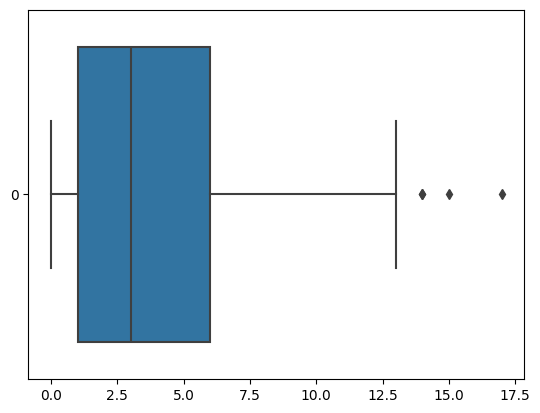

In [8]:
sns.boxplot(data.Pregnancies,orient='h')

<Axes: xlabel='Pregnancies', ylabel='count'>

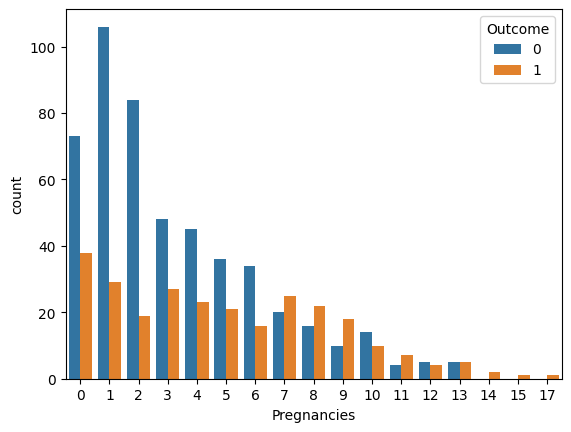

In [9]:
#sns.countplot(x=data.Pregnancies)
sns.countplot(x=data.Pregnancies,hue=data.Outcome)
#Insights: Count of 0-2 pregnancies is maximum, which means, about 40% ladies have 0-2 pregnancies as per the data given
#Insights: The chances of a non pregnant having a diabetes is 33%, 
#The data shows that the chances of women with 1 pregnancy getting diabetic is about 25%
#The data shows that the chances of women with 2 pregnancis getting diabetic is about 17%
#The data shows that People with more pregnancies (>13) have a higher risk of diabetes
#People with higher pregnancies(>7) are more than 50% probable to be diabetic

<Axes: xlabel='Pregnancies', ylabel='Count'>

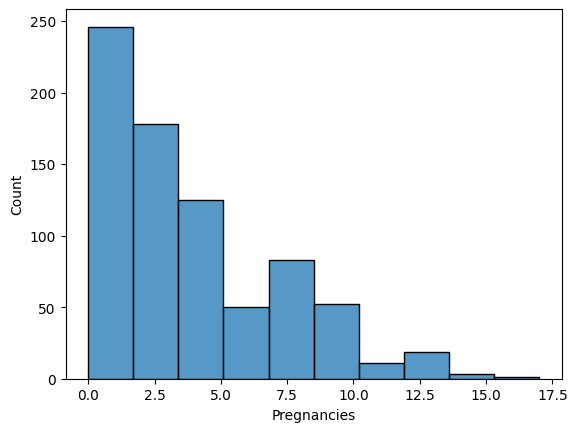

In [16]:
sns.histplot(data.Pregnancies, bins=10)

<Axes: xlabel='Glucose', ylabel='Count'>

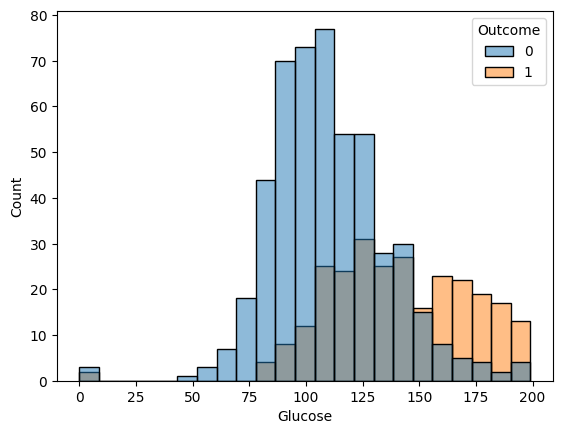

In [17]:
#sns.histplot(x=data.Glucose)
sns.histplot(x=data.Glucose,hue=data.Outcome)

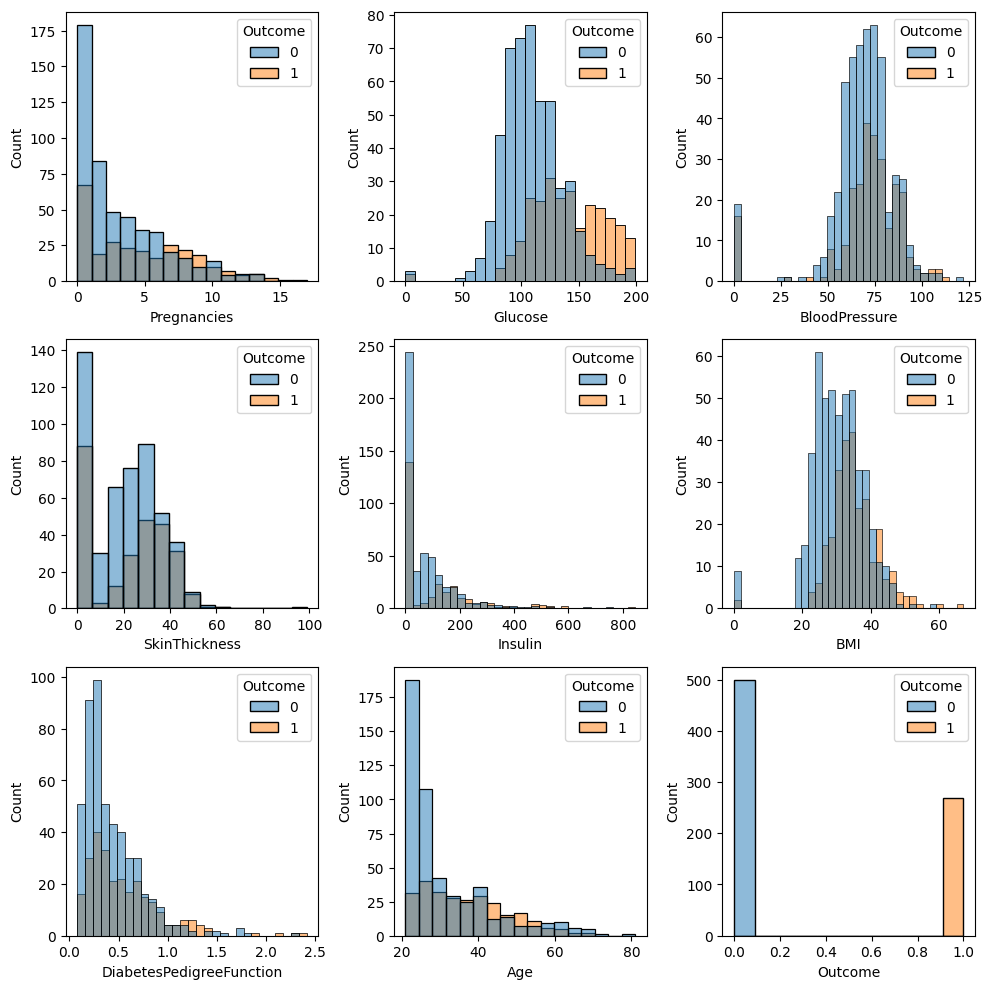

In [18]:
plt.figure(figsize=(10,10))
plotnumber = 1
for i in data:
    plt.subplot(3,3,plotnumber)
    #sns.histplot(x = data[i])
    sns.histplot(x = data[i],hue=data.Outcome)
    plotnumber += 1
plt.tight_layout()

### Insights
- Glucose: Most people seem to have glucose levels between 90-130 with entire range varying from 70-200, though we happen to have instances of 50-70 too
- BloodPressure: Most people seem to have bloodpressure between 70-80 with entire range varying from 50-110, though we happen to have instances of 25-50 and 110-120 too
- SkinThickness: Most people seem to have skinthickness between 0-7 with entire range varying from 0-57, though we happen to have instances of 57-65
- Insulin: 
- BMI: 
- DiabetesPedigreeFunction: 
- Age
- Using hue command, we realise that increase in glucose, bmi, blood pressure, the chances of diabetes is more. The rest features may not be significantly affecting the chances of diabetes

In [12]:
# pip install sweetviz

In [19]:
#!pip install sweetviz
import sweetviz as sv
my_report = sv.analyze(data)
my_report.show_html()

                                             |                                             | [  0%]   00:00 ->…

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Data Preprocessing

In [14]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [15]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [16]:
data.loc[data['Glucose']==0,'Glucose'] = np.median(data.Glucose)

In [17]:
data.loc[data['Glucose']==0,'Glucose']

Series([], Name: Glucose, dtype: int64)

In [18]:
data.SkinThickness.unique()

array([35, 29,  0, 23, 32, 45, 19, 47, 38, 30, 41, 33, 26, 15, 36, 11, 31,
       37, 42, 25, 18, 24, 39, 27, 21, 34, 10, 60, 13, 20, 22, 28, 54, 40,
       51, 56, 14, 17, 50, 44, 12, 46, 16,  7, 52, 43, 48,  8, 49, 63, 99],
      dtype=int64)

In [19]:
data.Age.unique()

array([50, 31, 32, 21, 33, 30, 26, 29, 53, 54, 34, 57, 59, 51, 27, 41, 43,
       22, 38, 60, 28, 45, 35, 46, 56, 37, 48, 40, 25, 24, 58, 42, 44, 39,
       36, 23, 61, 69, 62, 55, 65, 47, 52, 66, 49, 63, 67, 72, 81, 64, 70,
       68], dtype=int64)

In [20]:
data.Insulin.unique()

array([  0,  94, 168,  88, 543, 846, 175, 230,  83,  96, 235, 146, 115,
       140, 110, 245,  54, 192, 207,  70, 240,  82,  36,  23, 300, 342,
       304, 142, 128,  38, 100,  90, 270,  71, 125, 176,  48,  64, 228,
        76, 220,  40, 152,  18, 135, 495,  37,  51,  99, 145, 225,  49,
        50,  92, 325,  63, 284, 119, 204, 155, 485,  53, 114, 105, 285,
       156,  78, 130,  55,  58, 160, 210, 318,  44, 190, 280,  87, 271,
       129, 120, 478,  56,  32, 744, 370,  45, 194, 680, 402, 258, 375,
       150,  67,  57, 116, 278, 122, 545,  75,  74, 182, 360, 215, 184,
        42, 132, 148, 180, 205,  85, 231,  29,  68,  52, 255, 171,  73,
       108,  43, 167, 249, 293,  66, 465,  89, 158,  84,  72,  59,  81,
       196, 415, 275, 165, 579, 310,  61, 474, 170, 277,  60,  14,  95,
       237, 191, 328, 250, 480, 265, 193,  79,  86, 326, 188, 106,  65,
       166, 274,  77, 126, 330, 600, 185,  25,  41, 272, 321, 144,  15,
       183,  91,  46, 440, 159, 540, 200, 335, 387,  22, 291, 39

In [21]:
data.loc[data['BloodPressure']==0,'BloodPressure'] = np.median(data.BloodPressure)
data.loc[data['SkinThickness']==0,'SkinThickness'] = np.median(data.SkinThickness)
data.loc[data['Insulin']==0,'Insulin'] = int(np.median(data.Insulin))
data.loc[data['BMI']==0,'BMI'] = np.median(data.BMI)
#data.loc[data['Insulin']>500,'Insulin'] = np.median(data.Insulin)
#data.loc[data['Insulin']>350,'Insulin'] = 350

In [22]:
#Blood pressure less than 40 is not possible in reality. So, i'm setting those values to 40, to indicate that they are on the lower side of BP
data.loc[data.BloodPressure<40,'BloodPressure']=40

In [23]:
data.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.207882,0.032568,-0.056022,0.021546,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218003,0.172143,0.357146,0.231400,0.137327,0.266909,0.492782
BloodPressure,0.207882,0.218003,1.000000,0.150971,-0.030579,0.288693,-0.002866,0.326583,0.167178
SkinThickness,0.032568,0.172143,0.150971,1.000000,0.238321,0.546951,0.142977,0.054514,0.189065
Insulin,-0.056022,0.357146,-0.030579,0.238321,1.000000,0.188976,0.178173,-0.015892,0.148152
BMI,0.021546,0.231400,0.288693,0.546951,0.188976,1.000000,0.153506,0.025744,0.312249
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002866,0.142977,0.178173,0.153506,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.326583,0.054514,-0.015892,0.025744,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.167178,0.189065,0.148152,0.312249,0.173844,0.238356,1.000000


<Axes: >

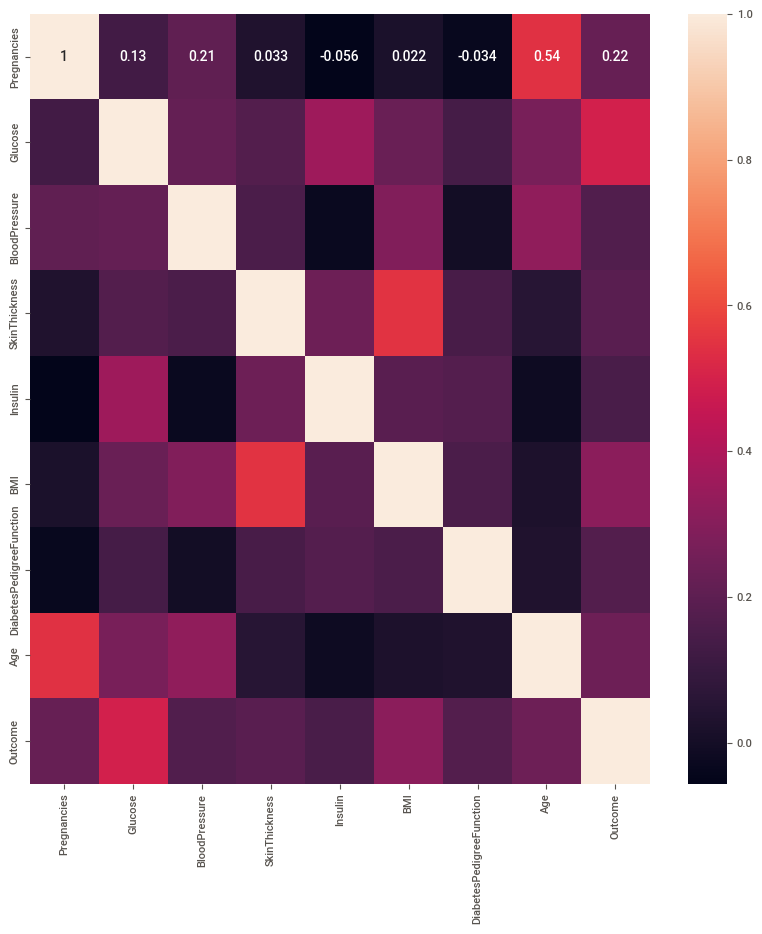

In [24]:
plt.figure(figsize = (10,10))
sns.heatmap(data.corr(),annot=True)

### Modeling

In [25]:
#Feature Target separation
X = data.drop('Outcome',axis=1)
Y = data.Outcome

In [26]:
Y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [27]:
#Test-train split
from sklearn.model_selection import train_test_split
x_train_raw,x_test_raw,y_train,y_test = train_test_split(X,Y,test_size = 0.25, random_state = 42)

In [28]:
from sklearn.preprocessing import MinMaxScaler
scal = MinMaxScaler()
X_scaled = scal.fit_transform(x_train_raw)

In [29]:
X_scaled

array([[0.76470588, 0.5483871 , 0.3902439 , ..., 0.44376278, 0.20964987,
        0.38333333],
       [0.23529412, 0.5483871 , 0.56097561, ..., 0.34560327, 0.06532878,
        0.03333333],
       [0.17647059, 0.10967742, 0.51219512, ..., 0.33128834, 0.0704526 ,
        0.41666667],
       ...,
       [0.58823529, 0.36774194, 0.56097561, ..., 0.5603272 , 0.45175064,
        0.28333333],
       [0.        , 0.62580645, 0.3902439 , ..., 0.49488753, 0.05422716,
        0.13333333],
       [0.        , 0.52258065, 0.68292683, ..., 0.08793456, 0.07856533,
        0.        ]])

In [30]:
x_train = pd.DataFrame(data=X_scaled,columns = data.columns[:8])

In [31]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.764706,0.548387,0.390244,0.400000,0.019231,0.443763,0.209650,0.383333
1,0.235294,0.548387,0.560976,0.218182,0.307692,0.345603,0.065329,0.033333
2,0.176471,0.109677,0.512195,0.363636,0.019231,0.331288,0.070453,0.416667
3,0.117647,0.238710,0.390244,0.127273,0.074519,0.243354,0.200256,0.066667
4,0.000000,0.374194,0.426829,0.272727,0.019231,0.282209,0.210931,0.000000
...,...,...,...,...,...,...,...,...
571,0.294118,0.612903,0.292683,0.490909,0.151442,0.212679,0.142186,0.083333
572,0.058824,0.335484,1.000000,0.272727,0.019231,0.085890,0.055081,0.100000
573,0.588235,0.367742,0.560976,0.527273,0.019231,0.560327,0.451751,0.283333
574,0.000000,0.625806,0.390244,0.272727,0.019231,0.494888,0.054227,0.133333


In [32]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [33]:
X_test = scal.transform(x_test_raw)
x_test = pd.DataFrame(data=X_test,columns = data.columns[:8])
y_pred = LR.predict(x_test)

In [34]:
x1 = pd.DataFrame()
x1[0] = y_pred
x1[1] = y_test.values
x1[2] = y_pred-y_test.values
x1.rename(columns={0: "Y_pred"}, inplace=True)
x1.rename(columns={1: "Y_test"}, inplace=True)
x1.rename(columns={2: "Error"}, inplace=True)
x1

,Y_pred,Y_test,Error
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
187,0,0,0
188,1,1,0
189,0,0,0
190,0,1,-1


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [36]:
acc = accuracy_score(y_test,y_pred)
print('Accuracy:',acc)
pr = precision_score(y_test,y_pred)
re = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print('Precision:',pr,'\nRecall:', re,'\nF1Score', f1, '\nConfusion Matrix\n', cm)
print('Classification Report:\n',classification_report(y_test,y_pred))

Accuracy: 0.7395833333333334
Precision: 0.6557377049180327 
Recall: 0.5797101449275363 
F1Score 0.6153846153846154 
Confusion Matrix
 [[102  21]
 [ 29  40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.80       123
           1       0.66      0.58      0.62        69

    accuracy                           0.74       192
   macro avg       0.72      0.70      0.71       192
weighted avg       0.73      0.74      0.74       192



## Multi class classification:
- Since its hard to draw a single line to classify classes, we use a concept called, OVR (One Versus Rest)
- We create same number of models as number of classes.
- Each model will take a class, and seggregate it against the rest
- Eg, 3 classes, A,B,C. Model1 will draw a seggregation line with A vs Rest, similarly Model2 is B vs Rest, Model3 is C vs Rest. Each time a datapoint comes, we apply 3 models to calculate probability of the point to in class A, B, C. If P(A) = 0.2, P(B)=0.5, P(C)=0.3, we classify the point to be class B, coz that P is more

In [3]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic',
 'anagrams',
 'anagrams',
 'anscombe',
 'anscombe',
 'attention',
 'attention',
 'brain_networks',
 'brain_networks',
 'car_crashes',
 'car_crashes',
 'diamonds',
 'diamonds',
 'dots',
 'dots',
 'dowjones',
 'dowjones',
 'exercise',
 'exercise',
 'flights',
 'flights',
 'fmri',
 'fmri',
 'geyser',
 'geyser',
 'glue',
 'glue',
 'healthexp',
 'healthexp',
 'iris',
 'iris',
 'mpg',
 'mpg',
 'penguins',
 'penguins',
 'planets',
 'planets',
 'seaice',
 'seaice',
 'taxis',
 'taxis',
 'tips',
 'tips',
 'titanic',
 'titanic',
 'anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'plan

In [4]:
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [5]:
# iris = pd.read_csv("Iris.csv")
iris.species.value_counts()  #Value counts done to see the balance in data

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [6]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [11]:
from sklearn.model_selection import *

In [7]:
x = iris.drop(['species'], axis=1)
y = iris.species

In [12]:
xtrain_raw,xtest_raw,ytrain,ytest = train_test_split(x,y,test_size = 0.25,random_state = 30)

In [13]:
# Model Creation  - Demonstrating multi class classification using logistic Regression
from sklearn.preprocessing import StandardScaler
scaler1 = StandardScaler()
col = x.columns
x_new = scaler1.fit_transform(xtrain_raw)  #Scaling done so that the model normalises all data, else, some columns may be given more weigtages by model
xtrain = pd.DataFrame(data=x_new,columns = col)


In [15]:
x_new

array([[ 0.31610695, -0.64360975,  0.15152306,  0.14615138],
       [ 1.68257629, -0.19448644,  1.18004322,  0.54539418],
       [ 1.18567835,  0.25463688,  1.23718323,  1.47696072],
       [ 0.68878041, -0.64360975,  1.0657632 ,  1.21079885],
       [-0.05656651,  2.05113014, -1.44839719, -1.31773889],
       [ 0.44033144, -1.99097969,  0.4372231 ,  0.41231325],
       [ 0.68878041, -0.86817141,  0.89434317,  0.94463699],
       [-0.80191342, -0.86817141,  0.09438305,  0.27923232],
       [-0.30501548, -0.86817141,  0.26580308,  0.14615138],
       [ 0.31610695, -0.64360975,  0.55150312,  0.01307045],
       [-0.42923996, -1.31729472,  0.15152306,  0.14615138],
       [-0.30501548, -0.19448644,  0.20866307,  0.14615138],
       [-1.54726034,  0.70376019, -1.33411717, -1.18465796],
       [-0.05656651, -0.86817141,  0.20866307, -0.25309142],
       [ 1.06145387,  0.47919854,  1.12290321,  1.74312259],
       [-0.05656651, -1.09273307,  0.15152306,  0.01307045],
       [-0.92613791,  1.

In [14]:
xtrain

,sepal_length,sepal_width,petal_length,petal_width
0,0.316107,-0.643610,0.151523,0.146151
1,1.682576,-0.194486,1.180043,0.545394
2,1.185678,0.254637,1.237183,1.476961
3,0.688780,-0.643610,1.065763,1.210799
4,-0.056567,2.051130,-1.448397,-1.317739
...,...,...,...,...
107,-0.429240,-1.766418,0.151523,0.146151
108,1.931025,-0.643610,1.351463,0.944637
109,1.061454,0.030075,1.065763,1.610042
110,-1.298811,-0.194486,-1.334117,-1.184658


In [16]:
x_new = scaler1.transform(xtest_raw)
xtest = pd.DataFrame(data=x_new,columns = col)

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
#print(xtrain,xtest,ytrain,ytest)
LR1 = LogisticRegression(multi_class='ovr')
LR1.fit(xtrain,ytrain)
ypred = LR1.predict(xtest)
x2 = pd.DataFrame()
x2[0] = ypred
x2[1] = ytest.values
x2.rename(columns={0: "Y_pred"}, inplace=True)
x2.rename(columns={1: "Y_test"}, inplace=True)
x2

,Y_pred,Y_test
0,setosa,setosa
1,setosa,setosa
2,setosa,setosa
3,virginica,virginica
4,versicolor,versicolor
5,versicolor,versicolor
6,virginica,virginica
7,virginica,virginica
8,versicolor,versicolor
9,virginica,virginica


In [23]:
from sklearn.metrics import *

In [29]:
print(accuracy_score(ytest,ypred))
print(precision_score(ytest,ypred,average='weighted'))
print(recall_score(ytest,ypred,average='weighted'))
print(f1_score(ytest,ypred,average='weighted'))
print("\n")

print( pd.crosstab(ytest,ypred))
print("\n")
print(classification_report(ytest,ypred))

0.9473684210526315
0.9473684210526315
0.9473684210526315
0.9473684210526315


col_0       setosa  versicolor  virginica
species                                  
setosa          12           0          0
versicolor       0          10          1
virginica        0           1         14


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.91      0.91      0.91        11
   virginica       0.93      0.93      0.93        15

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38

